Vorbereitung auf Modelle pro Familien-Gruppe. Das macht aus Memory-Sicht mehr Sinn, aber auch, weil die Produkte in den Familien ganz unterschiedliche Kaufzyklen haben


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [12]:
# Pfade bei Bedarf anpassen
BASE_DIR = Path(r"C:\Users\nelid\Documents\Kaggle Competitions\Store Sales Competition\store-sales")
RAW_DIR       = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

# Rohdaten laden

train        = pd.read_csv(RAW_DIR / "train.csv",            parse_dates=["date"])
test         = pd.read_csv(RAW_DIR / "test.csv",             parse_dates=["date"])
stores       = pd.read_csv(RAW_DIR / "stores.csv")
oil          = pd.read_csv(RAW_DIR / "oil.csv",              parse_dates=["date"])
holidays     = pd.read_csv(RAW_DIR / "holidays_events.csv",  parse_dates=["date"])
transactions = pd.read_csv(RAW_DIR / "transactions.csv",     parse_dates=["date"])



In [13]:
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [14]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


In [15]:
# Holiday Features

# Nur nationale Feiertage (type == "Holiday"), keine lokalen
nat_hol = holidays[
    (holidays["locale"] == "National") &
    (holidays["transferred"] == False)
][["date", "type", "description"]].copy()
nat_hol = nat_hol.rename(columns={"description": "holiday_name"})

# Alle Holiday-Typen als binäre Flags
hol_pivot = pd.get_dummies(
    holidays.assign(val=1)[["date","type","val"]].drop_duplicates(),
    columns=["type"], prefix="hol"
).groupby("date").max().reset_index()

# Einfache Flags
holiday_daily = (
    holidays.groupby("date")
    .agg(
        is_holiday_observed  = ("type", lambda x: int("Holiday" in x.values)),
        is_additional_holiday= ("type", lambda x: int("Additional" in x.values)),
        is_bridge_day        = ("type", lambda x: int("Bridge" in x.values)),
        is_work_day_comp     = ("type", lambda x: int("Work Day" in x.values)),
        is_transferred_flag  = ("transferred", "max"),
        holiday_names        = ("description", lambda x: "|".join(x.unique()))
    )
    .reset_index()
)
holiday_daily["is_holiday_weekend"] = (
    holiday_daily["is_holiday_observed"] &
    holiday_daily["date"].dt.dayofweek.isin([5, 6])
).astype(int)

holiday_daily.to_csv(PROCESSED_DIR / "holiday_features_daily_v2.csv", index=False)

train = train.merge(holiday_daily, on="date", how="left")
test  = test.merge(holiday_daily,  on="date", how="left")

# NaN-Füllung bei Holiday-Spalten
hol_cols = [c for c in holiday_daily.columns if c != "date"]
train[hol_cols] = train[hol_cols].fillna({"holiday_names": "none"}).fillna(0)
test[hol_cols]  = test[hol_cols].fillna({"holiday_names": "none"}).fillna(0)

In [17]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 13 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   id                     int64         
 1   date                   datetime64[ns]
 2   store_nbr              int64         
 3   family                 object        
 4   sales                  float64       
 5   onpromotion            int64         
 6   is_holiday_observed    float64       
 7   is_additional_holiday  float64       
 8   is_bridge_day          float64       
 9   is_work_day_comp       float64       
 10  is_transferred_flag    object        
 11  holiday_names          object        
 12  is_holiday_weekend     float64       
dtypes: datetime64[ns](1), float64(6), int64(3), object(3)
memory usage: 297.6+ MB


In [19]:
# Ein Binary-Flag: irgendeine Art Feiertag an diesem Tag?
train["is_any_holiday"] = (
    train["is_holiday_observed"].astype(int)
    | train["is_additional_holiday"].astype(int)
    | train["is_bridge_day"].astype(int)
    | train["is_work_day_comp"].astype(int)
    | train["is_transferred_flag"].astype(int)
    | train["is_holiday_weekend"].astype(int)
)

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 14 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   id                     int64         
 1   date                   datetime64[ns]
 2   store_nbr              int64         
 3   family                 object        
 4   sales                  float64       
 5   onpromotion            int64         
 6   is_holiday_observed    float64       
 7   is_additional_holiday  float64       
 8   is_bridge_day          float64       
 9   is_work_day_comp       float64       
 10  is_transferred_flag    object        
 11  holiday_names          object        
 12  is_holiday_weekend     float64       
 13  is_any_holiday         int64         
dtypes: datetime64[ns](1), float64(6), int64(4), object(3)
memory usage: 320.5+ MB


In [20]:
# Annahme: train enthält Spalten: date, family, sales, onpromotion, is_holiday (0/1)

# Promotion-Features pro Family
promo_feats = (
    train
    .groupby("family")
    .agg(
        promo_days=("onpromotion", lambda x: (x > 0).sum()),
        total_days=("onpromotion", "size"),
        promo_sales=("sales", lambda s: s[train.loc[s.index, "onpromotion"] > 0].mean()),
        nonpromo_sales=("sales", lambda s: s[train.loc[s.index, "onpromotion"] == 0].mean()),
    )
)

promo_feats["promo_day_share"] = promo_feats["promo_days"] / promo_feats["total_days"]
promo_feats["promo_uplift"] = promo_feats["promo_sales"] - promo_feats["nonpromo_sales"]

promo_feats = promo_feats[[
    "promo_day_share",
    "promo_uplift",
]]

# Holiday-Features pro Family
holiday_feats = (
    train
    .groupby("family")
    .agg(
        holiday_days=("is_any_holiday", "sum"),
        total_days=("is_any_holiday", "size"),
        holiday_sales=("sales", lambda s: s[train.loc[s.index, "is_any_holiday"] == 1].mean()
                       if (train.loc[s.index, "is_any_holiday"] == 1).any() else 0.0),
        nonholiday_sales=("sales", lambda s: s[train.loc[s.index, "is_any_holiday"] == 0].mean())
    )
)

holiday_feats["holiday_day_share"] = (
    holiday_feats["holiday_days"] / holiday_feats["total_days"]
)
holiday_feats["holiday_uplift"] = (
    holiday_feats["holiday_sales"] - holiday_feats["nonholiday_sales"]
)

holiday_feats = holiday_feats[[
    "holiday_day_share",
    "holiday_uplift",
]]



In [21]:
holiday_feats.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33 entries, AUTOMOTIVE to SEAFOOD
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   holiday_day_share  33 non-null     float64
 1   holiday_uplift     33 non-null     float64
dtypes: float64(2)
memory usage: 792.0+ bytes


Gespeichert: C:\Users\nelid\Documents\Kaggle Competitions\Store Sales Competition\store-sales\notebooks\outputs\family_daily_sales_overview.png
Liste der Familien gespeichert nach: C:\Users\nelid\Documents\Kaggle Competitions\Store Sales Competition\store-sales\notebooks\outputs\families_list.csv


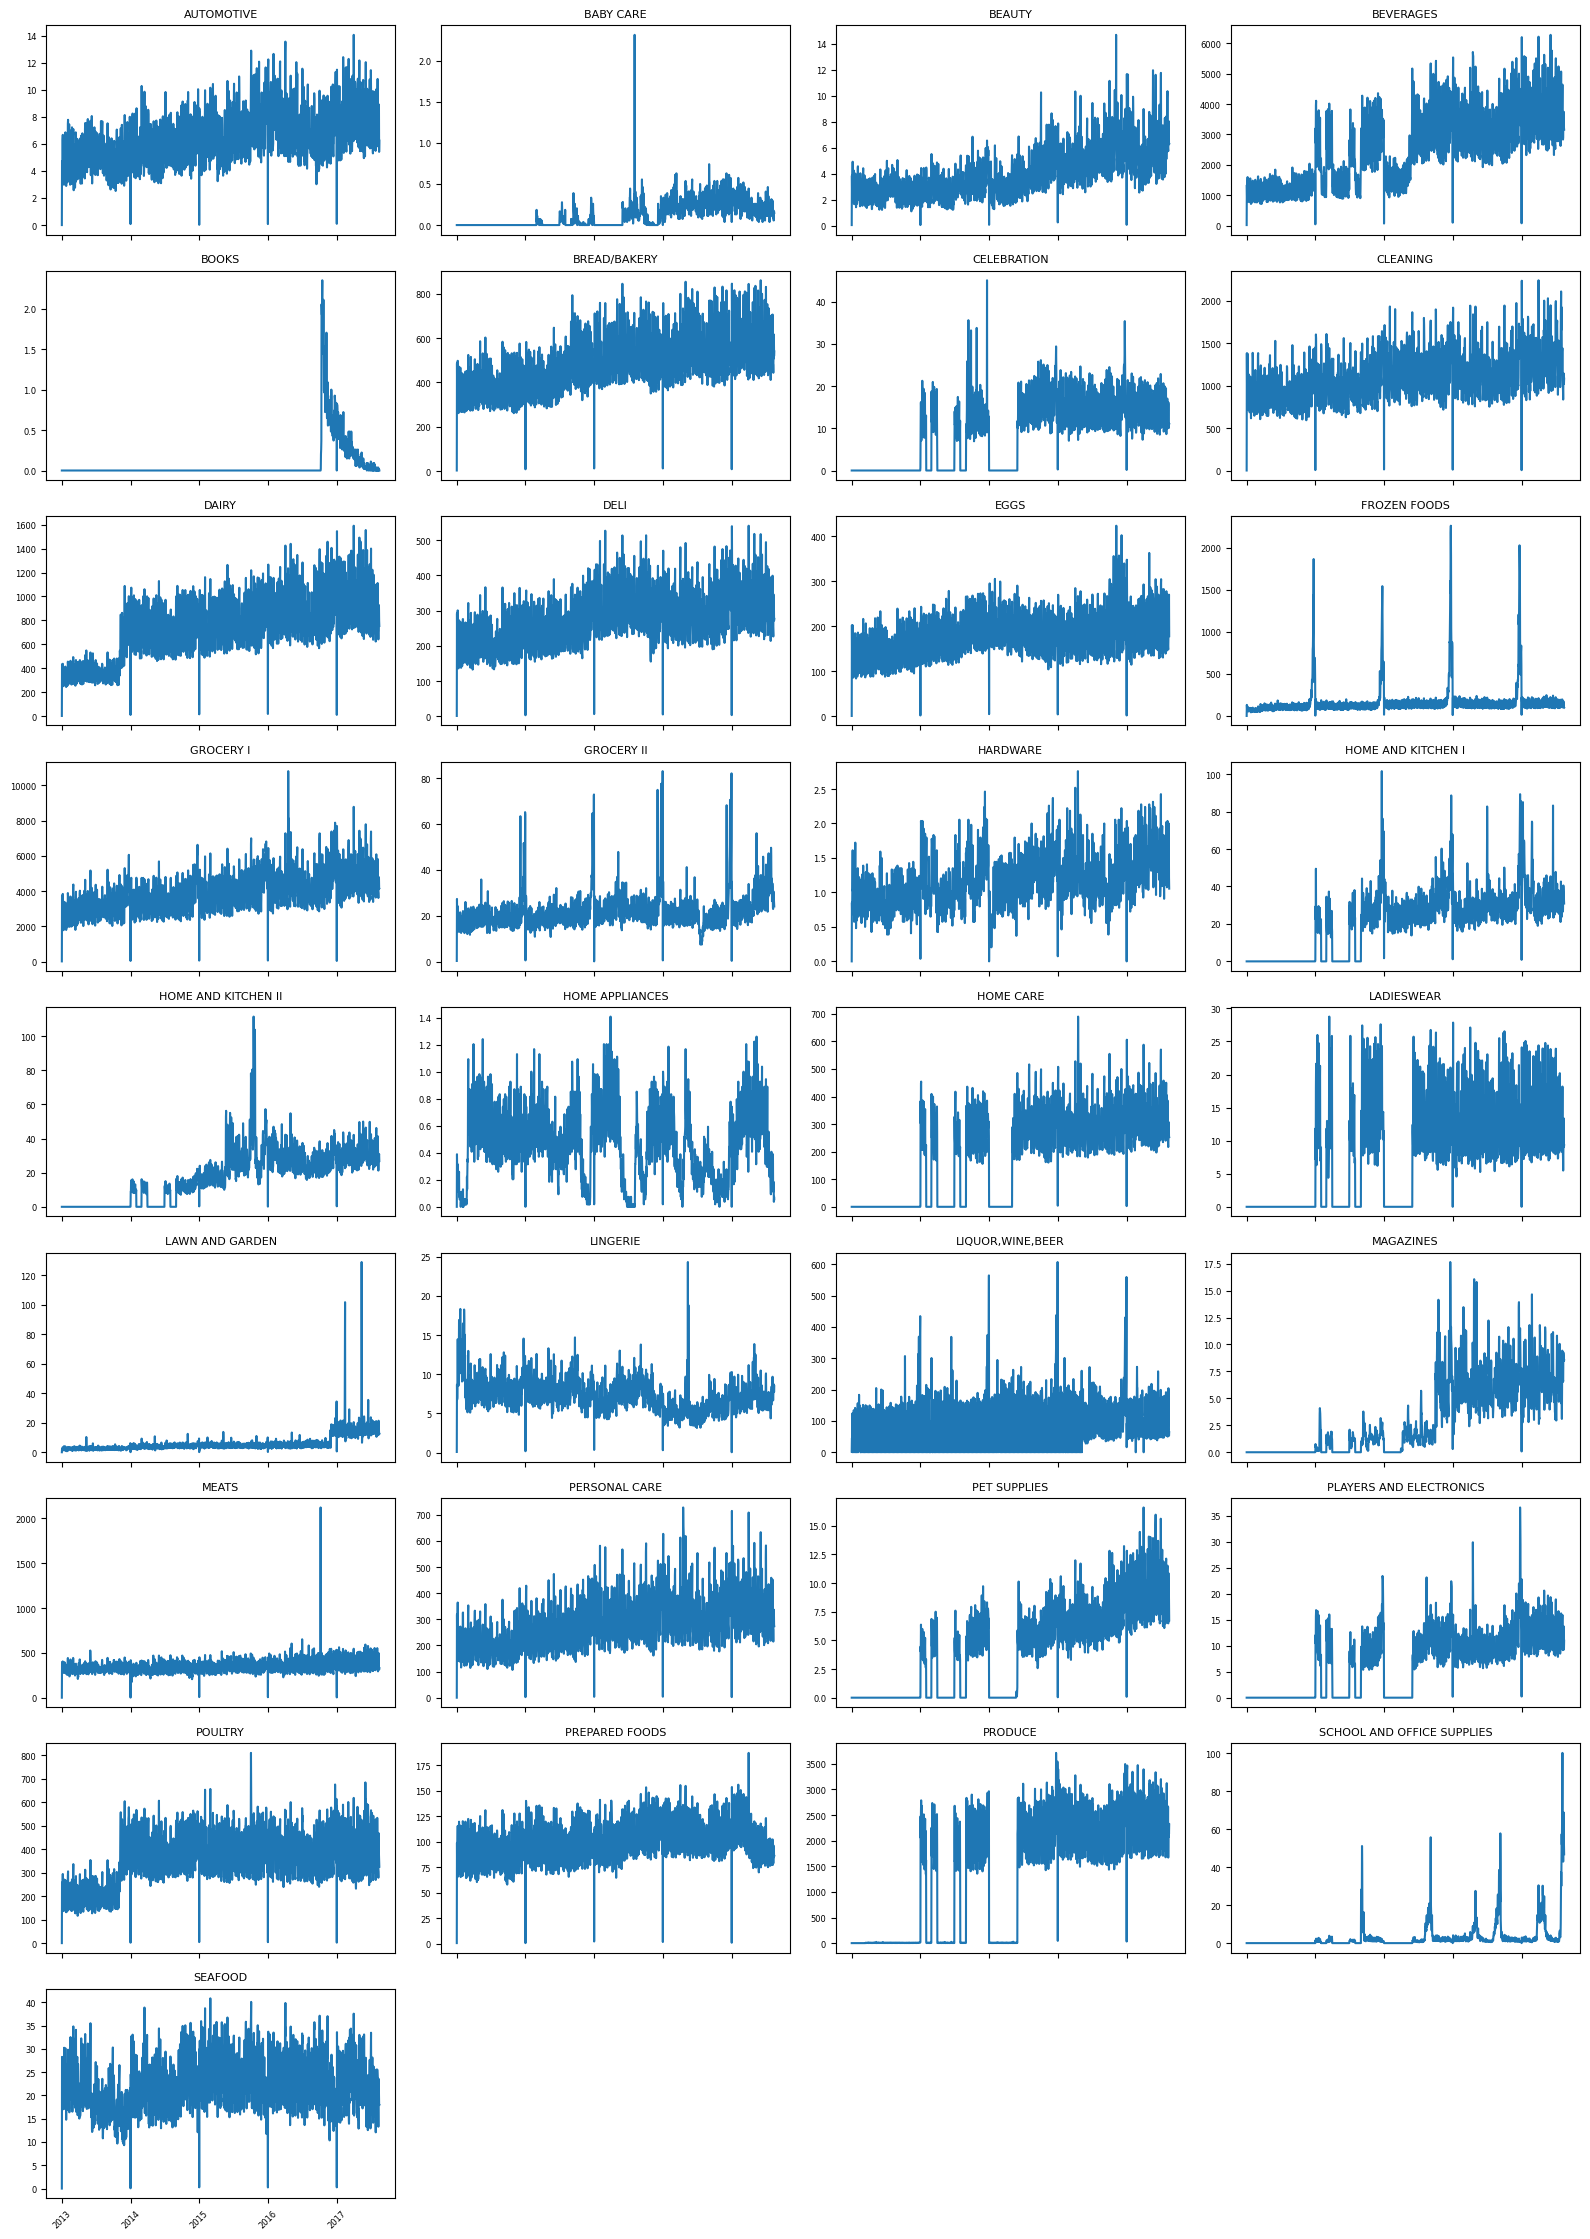

In [22]:
# 2) Aggregation: durchschnittliche Sales pro Family und Tag
family_daily = (
    train
    .groupby(["family", "date"], as_index=False)["sales"]
    .mean()
)

# 3) Nach Datum sortieren
family_daily = family_daily.sort_values(["family", "date"])

# 4) Plot: eine Figure mit Subplots, je Family eine Zeitreihe
families = family_daily["family"].unique()

n_fam = len(families)
n_cols = 4
n_rows = (n_fam + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 2.5 * n_rows),
    sharex=True
)
axes = axes.flatten()

for ax, fam in zip(axes, families):
    tmp = family_daily[family_daily["family"] == fam]
    ax.plot(tmp["date"], tmp["sales"])
    ax.set_title(fam, fontsize=8)
    ax.tick_params(axis="x", labelrotation=45, labelsize=6)
    ax.tick_params(axis="y", labelsize=6)

# Leere Subplots ausblenden
for ax in axes[n_fam:]:
    ax.axis("off")

fig.tight_layout()

# 5) Figure speichern
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)
fig_path = OUT_DIR / "family_daily_sales_overview.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")

print(f"Gespeichert: {fig_path.resolve()}")

# 6) Liste aller Families als CSV für spätere Gruppierung
families_path = OUT_DIR / "families_list.csv"
pd.DataFrame({"family": sorted(families)}).to_csv(families_path, index=False)
print(f"Liste der Familien gespeichert nach: {families_path.resolve()}")

In [23]:
family_daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55572 entries, 0 to 55571
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   family  55572 non-null  object        
 1   date    55572 non-null  datetime64[ns]
 2   sales   55572 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 1.3+ MB


Dendrogramm gespeichert unter: C:\Users\nelid\Documents\Kaggle Competitions\Store Sales Competition\store-sales\data\outputs\families_dendrogram.png
Clusterzuordnung gespeichert unter: C:\Users\nelid\Documents\Kaggle Competitions\Store Sales Competition\store-sales\data\outputs\family_clusters_hierarchical.csv


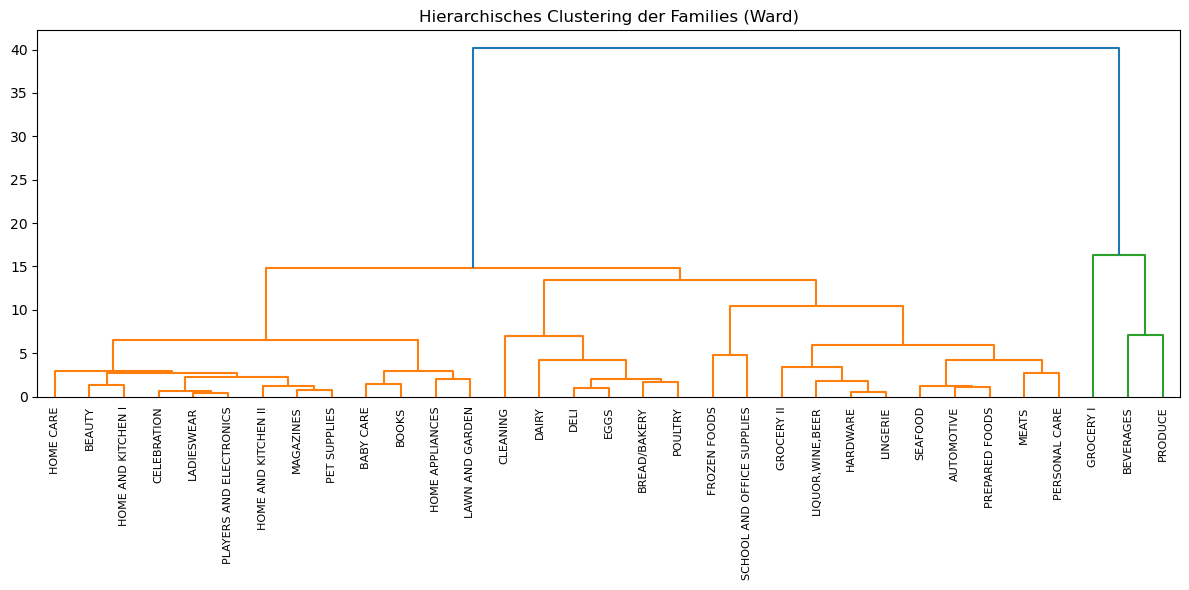

In [24]:
# Untersuche Familiengruppen mit hierarchisches Clustering

#import pandas as pd
import numpy as np
#from pathlib import Path

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

# family_daily: durchschnittliche Sales pro Family und Tag
family_daily = (
    train
    .groupby(["family", "date"], as_index=False)["sales"]
    .mean()
    .sort_values(["family", "date"])
)

# -----------------------------
# Feature-Engineering pro Family
# -----------------------------

# Level & Volatilität
level_vol = (
    family_daily
    .groupby("family")["sales"]
    .agg(["mean", "std"])
    .rename(columns={"mean": "sales_mean", "std": "sales_std"})
)

# Wochenprofil (7 Werte)
family_daily["weekday"] = family_daily["date"].dt.weekday  # 0=Montag
weekday_prof = (
    family_daily
    .groupby(["family", "weekday"])["sales"]
    .mean()
    .unstack("weekday")
    .fillna(0.0)
)
weekday_prof.columns = [f"wd_{c}" for c in weekday_prof.columns]

# Monatsprofil (12 Werte)
family_daily["month"] = family_daily["date"].dt.month
month_prof = (
    family_daily
    .groupby(["family", "month"])["sales"]
    .mean()
    .unstack("month")
    .fillna(0.0)
)
month_prof.columns = [f"m_{c}" for c in month_prof.columns]

# Trend via einfache lineare Regression (np.polyfit)
trends = []
for fam, grp in family_daily.groupby("family"):
    x = (grp["date"] - grp["date"].min()).dt.days.values.astype(float)
    y = grp["sales"].values.astype(float)
    if len(np.unique(x)) > 1:
        slope, intercept = np.polyfit(x, y, 1)
    else:
        slope, intercept = 0.0, y.mean() if len(y) > 0 else 0.0
    trends.append({"family": fam, "trend_slope": slope, "trend_intercept": intercept})

trends_df = pd.DataFrame(trends).set_index("family")

# Autokorrelation bei Lag 7, 14, 21, 28, 35, 42
def acf_at_lag(series, lag):
    s = series - series.mean()
    if len(s) <= lag:
        return 0.0
    return float(np.corrcoef(s[:-lag], s[lag:])[0, 1])

acfs = []
for fam, grp in family_daily.groupby("family"):
    s = grp.sort_values("date")["sales"].values.astype(float)
    acf7 = acf_at_lag(s, 7)
    acf14 = acf_at_lag(s, 14)
    acf21 = acf_at_lag(s, 21)
    acf28 = acf_at_lag(s, 28)
    acf35 = acf_at_lag(s, 35)
    acf42 = acf_at_lag(s, 42)
    acfs.append({
        "family": fam,
        "acf7": acf7,
        "acf14": acf14,
        "acf21": acf21,
        "acf28": acf28,
        "acf35": acf35,
        "acf42": acf42,
    })

acfs_df = pd.DataFrame(acfs).set_index("family")

# Rolling-Features je Family 
rolling_features = []

for fam, grp in family_daily.groupby("family"):
    grp_sorted = grp.sort_values("date").copy()
    s = grp_sorted["sales"]

    # 7- und 28-Tage-Rolling-Mean
    r7 = s.rolling(window=7, min_periods=1).mean()
    r28 = s.rolling(window=28, min_periods=1).mean()
    r56 = s.rolling(window=56, min_periods=1).mean()

    global_mean = s.mean() if s.mean() != 0 else 1.0

    dev7 = np.abs(r7 - global_mean) / global_mean
    dev28 = np.abs(r28 - global_mean) / global_mean
    dev56 = np.abs(r56- global_mean) / global_mean

    rolling_features.append({
        "family": fam,
        "roll7_mean": r7.mean(),
        "roll7_std": r7.std(),
        "roll28_mean": r28.mean(),
        "roll28_std": r28.std(),
        "roll56_mean": r56.mean(),
        "roll56_std": r56.std(),
        "roll7_large_dev_share": (dev7 > 0.3).mean(),
        "roll28_large_dev_share": (dev28 > 0.3).mean(),
        "roll56_large_dev_share": (dev56 >0.3).mean(),
    })

rolling_df = pd.DataFrame(rolling_features).set_index("family")

# 3) Feature-Matrix zusammenbauen
features = (
    level_vol
    .join(weekday_prof, how="left")
    .join(month_prof, how="left")
    .join(trends_df, how="left")
    .join(acfs_df, how="left")
    .join(rolling_df, how="left")
    .join(promo_feats, how="left")      # Promotion-Features (wie zuvor definiert)
    .join(holiday_feats, how="left")    # NEU: Holiday-Features auf Basis deiner Flags
)

features = features.fillna(0.0)


# 4) Standardisieren
scaler = StandardScaler()
X = scaler.fit_transform(features.values)

# 5) Hierarchisches Clustering (Ward-Linkage)
Z = linkage(X, method="ward")

# 6) Dendrogramm plotten und speichern
OUT_DIR = BASE_DIR / "data" / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 6))
dendrogram(Z, labels=features.index.tolist(), leaf_rotation=90)
plt.title("Hierarchisches Clustering der Families (Ward)")
plt.tight_layout()
fig_path = OUT_DIR / "families_dendrogram.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Dendrogramm gespeichert unter: {fig_path.resolve()}")

# 7) Cluster-Zuordnung erzeugen (z.B. 5 Cluster)
n_clusters = 5  # nach Blick aufs Dendrogramm anpassen
cluster_labels = fcluster(Z, n_clusters, criterion="maxclust")

family_clusters = pd.DataFrame({
    "family": features.index,
    "cluster": cluster_labels,
}).sort_values("cluster")

clusters_csv = OUT_DIR / "family_clusters_hierarchical.csv"
family_clusters.to_csv(clusters_csv, index=False)
print(f"Clusterzuordnung gespeichert unter: {clusters_csv.resolve()}")


In [28]:
# K-Means probieren

from sklearn.cluster import KMeans
import pandas as pd

# Anzahl Cluster für K-Means
k = 5  # je nach gewünschter Granularität (4–6 ist meist sinnvoll)

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init="auto",
)
kmeans_labels = kmeans.fit_predict(X)

family_kmeans = pd.DataFrame({
    "family": features.index,
    "kmeans_cluster": kmeans_labels,
}).sort_values("kmeans_cluster")

# Optional: hierarchische Cluster mergen, falls vorhanden
if "family_clusters" in globals():
    comparison = (
        family_clusters  # Spalten: family, cluster
        .merge(family_kmeans, on="family", how="left")
    )
else:
    comparison = family_kmeans

# Cluster-Tabelle sortiert ausgeben
display(
    comparison.sort_values(
        ["kmeans_cluster", "family"]
    ).reset_index(drop=True)
)


C:\Users\nelid\anaconda3\envs\store-sales-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,family,cluster,kmeans_cluster
0,GROCERY I,5,0
1,AUTOMOTIVE,3,1
2,BABY CARE,1,1
3,HARDWARE,3,1
4,HOME APPLIANCES,1,1
5,LAWN AND GARDEN,1,1
6,LINGERIE,3,1
7,"LIQUOR,WINE,BEER",3,1
8,MEATS,3,1
9,PERSONAL CARE,3,1


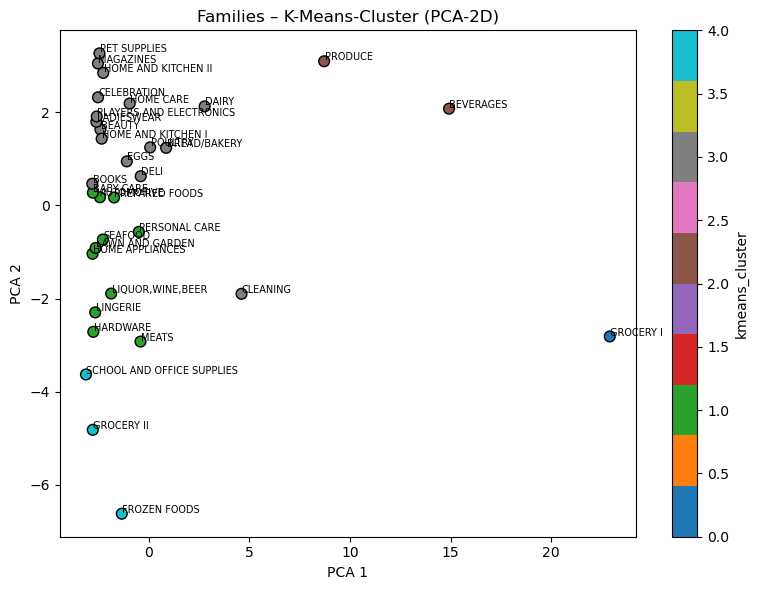

In [29]:
# Einfache 2D-Visualisierung (PCA)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=kmeans_labels,
    cmap="tab10",
    s=60,
    edgecolor="k",
)

for i, fam in enumerate(features.index):
    plt.text(
        X_2d[i, 0] + 0.02,
        X_2d[i, 1] + 0.02,
        fam,
        fontsize=7,
    )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Families – K-Means-Cluster (PCA-2D)")
plt.colorbar(scatter, label="kmeans_cluster")
plt.tight_layout()
plt.show()


In [30]:
# Dictionary mit Zuordnung von Family zu Gruppen:
family_to_group = {
    # Grocery I allein
    "GROCERY I": "grocery_I",

    # Top volume food
    "BEVERAGES": "top_volume_food",
    "PRODUCE": "top_volume_food",    
    
    # High Volume Food
    "BREAD/BAKERY": "high_volume_food",
    "DAIRY": "high_volume_food",
    "DELI": "high_volume_food",
    "POULTRY": "high_volume_food",
    "EGGS": "high_volume_food",
    "CLEANING": "high_volume_food",
 
    # Low Volume Food
    "MEATS": "low_volume_food",
    "SEAFOOD": "low_volume_food",    
    "PREPARED FOODS": "low_volume_food",

    # Mid Volume Mixed
    "HOME CARE": "mid_volume_mixed",       
    "BABY CARE": "mid_volume_mixed",
    "PERSONAL CARE": "mid_volume_mixed",
    "PET SUPPLIES": "mid_volume_mixed",
    "HOME AND KITCHEN I": "mid_volume_mixed",
    "HOME AND KITCHEN II": "mid_volume_mixed",
    "HOME APPLIANCES": "mid_volume_mixed",
    "BEAUTY": "mid_volume_mixed",
    "LADIESWEAR": "mid_volume_mixed",
    "LAWN AND GARDEN": "mid_volume_mixed",
    "PLAYERS AND ELECTRONICS": "mid_volume_mixed",
    "CELEBRATION": "mid_volume_mixed",
    "MAGAZINES": "mid_volume_mixed",
    "BOOKS": "mid_volume_mixed",

    # Low volume mixed
    "FROZEN FOODS": "low_volume_mixed",
    "SCHOOL AND OFFICE SUPPLIES": "low_volume_mixed",
    "GROCERY II": "low_volume_mixed",    
    

    # Low Volume / Special / Fashion / Media
    "HARDWARE": "low_volume_special",
    "AUTOMOTIVE": "low_volume_special",    
    "LINGERIE": "low_volume_special",
    "LIQUOR,WINE,BEER": "low_volume_special",
}


In [38]:
def add_family_group(df):
    df = df.copy()
    df["family_group"] = df["family"].map(family_to_group).fillna("other_family")
    return df



In [31]:
from pathlib import Path

module_code = """
family_to_group = {
    # Grocery I allein
    "GROCERY I": "grocery_I",

    # Top volume food
    "BEVERAGES": "top_volume_food",
    "PRODUCE": "top_volume_food",

    # High Volume Food
    "BREAD/BAKERY": "high_volume_food",
    "DAIRY": "high_volume_food",
    "DELI": "high_volume_food",
    "POULTRY": "high_volume_food",
    "EGGS": "high_volume_food",
    "CLEANING": "high_volume_food",

    # Low Volume Food
    "MEATS": "low_volume_food",
    "SEAFOOD": "low_volume_food",
    "PREPARED FOODS": "low_volume_food",

    # Mid Volume Mixed
    "HOME CARE": "mid_volume_mixed",
    "BABY CARE": "mid_volume_mixed",
    "PERSONAL CARE": "mid_volume_mixed",
    "PET SUPPLIES": "mid_volume_mixed",
    "HOME AND KITCHEN I": "mid_volume_mixed",
    "HOME AND KITCHEN II": "mid_volume_mixed",
    "HOME APPLIANCES": "mid_volume_mixed",
    "BEAUTY": "mid_volume_mixed",
    "LADIESWEAR": "mid_volume_mixed",
    "LAWN AND GARDEN": "mid_volume_mixed",
    "PLAYERS AND ELECTRONICS": "mid_volume_mixed",
    "CELEBRATION": "mid_volume_mixed",
    "MAGAZINES": "mid_volume_mixed",
    "BOOKS": "mid_volume_mixed",

    # Low volume mixed
    "FROZEN FOODS": "low_volume_mixed",
    "SCHOOL AND OFFICE SUPPLIES": "low_volume_mixed",
    "GROCERY II": "low_volume_mixed",

    # Low Volume / Special / Fashion / Media
    "HARDWARE": "low_volume_special",
    "AUTOMOTIVE": "low_volume_special",
    "LINGERIE": "low_volume_special",
    "LIQUOR,WINE,BEER": "low_volume_special",
}


def add_family_group(df):
    df = df.copy()
    df["family_group"] = df["family"].map(family_to_group).fillna("other_family")
    return df
"""

path = Path("src/config")
path.mkdir(parents=True, exist_ok=True)
(path / "family_groups.py").write_text(module_code)
print((path / "family_groups.py").resolve())

C:\Users\nelid\Documents\Kaggle Competitions\Store Sales Competition\store-sales\notebooks\src\config\family_groups.py


In [39]:
train = add_family_group(train)
test  = add_family_group(test)

In [40]:
# Check ob die Zuordnung funktioniert hat:
# import pandas as pd

# Annahme: train hat Spalten "family" und "family_group"
ct = pd.crosstab(train["family"], train["family_group"])
display(ct)


family_group,grocery_I,high_volume_food,low_volume_food,low_volume_mixed,low_volume_special,mid_volume_mixed,top_volume_food
family,,,,,,,
AUTOMOTIVE,0,0,0,0,90936,0,0
BABY CARE,0,0,0,0,0,90936,0
BEAUTY,0,0,0,0,0,90936,0
BEVERAGES,0,0,0,0,0,0,90936
BOOKS,0,0,0,0,0,90936,0
BREAD/BAKERY,0,90936,0,0,0,0,0
CELEBRATION,0,0,0,0,0,90936,0
CLEANING,0,90936,0,0,0,0,0
DAIRY,0,90936,0,0,0,0,0


In [42]:
family_to_group.keys()

dict_keys(['GROCERY I', 'BEVERAGES', 'PRODUCE', 'BREAD/BAKERY', 'DAIRY', 'DELI', 'POULTRY', 'EGGS', 'CLEANING', 'MEATS', 'SEAFOOD', 'PREPARED FOODS', 'HOME CARE', 'BABY CARE', 'PERSONAL CARE', 'PET SUPPLIES', 'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME APPLIANCES', 'BEAUTY', 'LADIESWEAR', 'LAWN AND GARDEN', 'PLAYERS AND ELECTRONICS', 'CELEBRATION', 'MAGAZINES', 'BOOKS', 'FROZEN FOODS', 'SCHOOL AND OFFICE SUPPLIES', 'GROCERY II', 'HARDWARE', 'AUTOMOTIVE', 'LINGERIE', 'LIQUOR,WINE,BEER'])

In [43]:
train["family"].unique()

array(['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS',
       'BREAD/BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS',
       'FROZEN FOODS', 'GROCERY I', 'GROCERY II', 'HARDWARE',
       'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME APPLIANCES',
       'HOME CARE', 'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE',
       'LIQUOR,WINE,BEER', 'MAGAZINES', 'MEATS', 'PERSONAL CARE',
       'PET SUPPLIES', 'PLAYERS AND ELECTRONICS', 'POULTRY',
       'PREPARED FOODS', 'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES',
       'SEAFOOD'], dtype=object)

In [41]:
# Konsistenzcheck. Ergebnis muss leere Sets sein:

families_in_train = set(train["family"].unique())
families_in_mapping = set(family_to_group.keys())

missing_in_mapping = families_in_train - families_in_mapping
extra_in_mapping = families_in_mapping - families_in_train

print("Fehlende Families im Mapping:", missing_in_mapping)
print("Nicht genutzte Mapping-Einträge:", extra_in_mapping)


Fehlende Families im Mapping: set()
Nicht genutzte Mapping-Einträge: set()


In [35]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 15 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   id                     int64         
 1   date                   datetime64[ns]
 2   store_nbr              int64         
 3   family                 object        
 4   sales                  float64       
 5   onpromotion            int64         
 6   is_holiday_observed    float64       
 7   is_additional_holiday  float64       
 8   is_bridge_day          float64       
 9   is_work_day_comp       float64       
 10  is_transferred_flag    object        
 11  holiday_names          object        
 12  is_holiday_weekend     float64       
 13  is_any_holiday         int64         
 14  family_group           object        
dtypes: datetime64[ns](1), float64(6), int64(4), object(4)
memory usage: 343.4+ MB


In [37]:
train.head()

,id,date,store_nbr,family,sales,onpromotion,is_holiday_observed,is_additional_holiday,is_bridge_day,is_work_day_comp,is_transferred_flag,holiday_names,is_holiday_weekend,is_any_holiday,family_group
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,1.0,0.0,0.0,0.0,False,Primer dia del ano,0.0,1,low_volume_special
1,1,2013-01-01,1,BABY CARE,0.0,0,1.0,0.0,0.0,0.0,False,Primer dia del ano,0.0,1,mid_volume_mixed
2,2,2013-01-01,1,BEAUTY,0.0,0,1.0,0.0,0.0,0.0,False,Primer dia del ano,0.0,1,mid_volume_mixed
3,3,2013-01-01,1,BEVERAGES,0.0,0,1.0,0.0,0.0,0.0,False,Primer dia del ano,0.0,1,top_volume_food
4,4,2013-01-01,1,BOOKS,0.0,0,1.0,0.0,0.0,0.0,False,Primer dia del ano,0.0,1,mid_volume_mixed


In [44]:
test.head()

,id,date,store_nbr,family,onpromotion,is_holiday_observed,is_additional_holiday,is_bridge_day,is_work_day_comp,is_transferred_flag,holiday_names,is_holiday_weekend,family_group
0,3000888,2017-08-16,1,AUTOMOTIVE,0,0.0,0.0,0.0,0.0,0,none,0.0,low_volume_special
1,3000889,2017-08-16,1,BABY CARE,0,0.0,0.0,0.0,0.0,0,none,0.0,mid_volume_mixed
2,3000890,2017-08-16,1,BEAUTY,2,0.0,0.0,0.0,0.0,0,none,0.0,mid_volume_mixed
3,3000891,2017-08-16,1,BEVERAGES,20,0.0,0.0,0.0,0.0,0,none,0.0,top_volume_food
4,3000892,2017-08-16,1,BOOKS,0,0.0,0.0,0.0,0.0,0,none,0.0,mid_volume_mixed


In [45]:
train.to_csv(PROCESSED_DIR / "train_family_groups_holidays.csv", index=False)
test.to_csv(PROCESSED_DIR / "test_family_groups_holidays.csv", index=False)